In [20]:
# Импортируем все полезное нам
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostRegressor
from IPython.display import display
from lightgbm import LGBMRegressor
from sklearn import set_config
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    TimeSeriesSplit,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [21]:
# Фиксируем сид
SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 1)
np.random.seed(SEED)

In [22]:
set_config(transform_output="pandas")

In [23]:
# Настройки визуализации
sns.set_theme(rc={"figure.figsize": (12, 6)}, palette="muted")
current_palette = sns.color_palette()
plt.style.use("ggplot")

In [24]:
# Загрузка данных
df = pd.read_csv("../data/raw/london_merged.csv")

In [25]:
# Feature Engineering
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month

In [26]:
# Как выявлено в EDA, логарифмизация cnt может быть полезна для работы моделей
df["cnt_log"] = np.log1p(df["cnt"])

# Чтобы модели лучше понимали цикличность времени суток,
# преобразуем часы в синус и косинус
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

In [27]:
def get_rmse_and_r2(y, y_pred):
    y_real = np.expm1(y)
    y_pred_real = np.expm1(y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred_real))

    return rmse, r2_score(y_real, y_pred_real)

In [28]:
categorical_features = ["weather_code", "season", "is_holiday", "is_weekend"]
numerical_features = [
    "hour_sin",
    "hour_cos",
    "day_of_week",
    "month",
    "t1",
    "t2",
    "hum",
    "wind_speed",
]

X = df[categorical_features + numerical_features]
y = df["cnt_log"]

Основываясь на смысле датасета, правильнее будет использовать не шаффл, а отдельный `TimeSeriesSplit`.

In [29]:
n = len(X)
train_val_size = int(n * 0.8)
test_size = n - train_val_size

X_train_val, X_test = X[:train_val_size], X[train_val_size:]
y_train_val, y_test = y[:train_val_size], y[train_val_size:]

tscv = TimeSeriesSplit(n_splits=5)

splits = list(tscv.split(X_train_val))
last_train_idx, last_val_idx = splits[-1]

X_train = X_train_val.iloc[last_train_idx]
X_val = X_train_val.iloc[last_val_idx]
y_train = y_train_val.iloc[last_train_idx]
y_val = y_train_val.iloc[last_val_idx]

print(f"Train: {len(X_train)} ({len(X_train) / n:.1%})")
print(f"Val:   {len(X_val)} ({len(X_val) / n:.1%})")
print(f"Test:  {len(X_test)} ({len(X_test) / n:.1%})")

Train: 11610 (66.7%)
Val:   2321 (13.3%)
Test:  3483 (20.0%)


In [30]:
preprocessor_preview = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ],
    remainder="passthrough",
)

X_train_preview = preprocessor_preview.fit_transform(X_train)
n_features_after_encoding = X_train_preview.shape[1]

print(f"Количество признаков до препроцессинга: {X_train.shape[1]}")
print(f"Количество признаков после one-hot encoding: {n_features_after_encoding}")

Количество признаков до препроцессинга: 12
Количество признаков после one-hot encoding: 23


Число признаков (23) не достаточно большое, чтобы оправдать уменьшение размерности.

Запускаем несколько моделей, включая ансамбли. Для каждой модели используем `GridSearchCV` на временных фолдах и затем оцениваем лучшую конфигурацию на отдельной validation-выборке.

In [31]:
# Препроцессинг

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ],
    remainder="passthrough",
)

In [32]:
experiments = [
    {
        "name": "Ridge",
        "model": Ridge(random_state=SEED),
        "params": {"regressor__alpha": [0.1, 1.0, 10.0]},
    },
    {
        "name": "KNN",
        "model": KNeighborsRegressor(),
        "params": {
            "regressor__n_neighbors": [5, 10, 20],
            "regressor__weights": ["uniform", "distance"],
        },
    },
    {
        "name": "Decision Tree",
        "model": DecisionTreeRegressor(random_state=SEED),
        "params": {
            "regressor__max_depth": [6, 10, 14],
            "regressor__min_samples_leaf": [1, 3, 5],
        },
    },
    {
        "name": "Random Forest",
        "model": RandomForestRegressor(random_state=SEED),
        "params": {
            "regressor__n_estimators": [100, 200],
            "regressor__max_depth": [10, 12, 14],
            "regressor__min_samples_leaf": [3, 5],
        },
    },
    {
        "name": "XGBoost",
        "model": XGBRegressor(objective="reg:squarederror", random_state=SEED),
        "params": {
            "regressor__n_estimators": [300, 500],
            "regressor__learning_rate": [0.05, 0.1],
            "regressor__max_depth": [4, 6],
            "regressor__subsample": [0.8, 1.0],
            "regressor__colsample_bytree": [0.8],
        },
    },
    {
        "name": "LightGBM",
        "model": LGBMRegressor(random_state=SEED, verbose=-1),
        "params": {
            "regressor__n_estimators": [300, 500],
            "regressor__learning_rate": [0.05, 0.1],
            "regressor__num_leaves": [31, 63],
            "regressor__feature_fraction": [0.8, 0.9],
        },
    },
    {
        "name": "CatBoost",
        "model": CatBoostRegressor(
            random_state=SEED, verbose=0, allow_writing_files=False
        ),
        "params": {
            "regressor__iterations": [300, 500],
            "regressor__learning_rate": [0.05, 0.1],
            "regressor__depth": [4, 6, 8],
            "regressor__l2_leaf_reg": [3, 5],
        },
    },
    {
        "name": "SVR",
        "model": SVR(),
        "params": {
            "regressor__C": [1.0, 5.0],
            "regressor__epsilon": [0.05, 0.1],
            "regressor__kernel": ["rbf"],
        },
    },
]

In [33]:
results_list = []

for exp in experiments:
    print(f"Провожу эксперимент для: {exp['name']}")

    # Создаем пайплайн с текущей моделью
    full_pipeline = Pipeline(
        steps=[("preprocessor", preprocessor), ("regressor", exp["model"])]
    )

    # Запускаем GridSearch на train_val выборке
    grid = GridSearchCV(
        full_pipeline,
        exp["params"],
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
    )

    grid.fit(X_train, y_train)

    # Валидация на отложенном фолде
    y_val_pred = grid.predict(X_val)

    rmse, r2 = get_rmse_and_r2(y_val, y_val_pred)
    grid_size = len(list(ParameterGrid(exp["params"])))

    results_list.append(
        {
            "Model": exp["name"],
            "Grid size": grid_size,
            "Best Params": grid.best_params_,
            "RMSE_val": round(rmse, 4),
            "R2_val": round(r2, 4),
        }
    )

Провожу эксперимент для: Ridge
Провожу эксперимент для: KNN
Провожу эксперимент для: Decision Tree
Провожу эксперимент для: Random Forest
Провожу эксперимент для: XGBoost
Провожу эксперимент для: LightGBM
Провожу эксперимент для: CatBoost
Провожу эксперимент для: SVR


In [34]:
results_df = pd.DataFrame(results_list).sort_values(by="RMSE_val")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"\nАбсолютно лучшая модель: {best_model_name}")

,Model,Grid size,Best Params,RMSE_val,R2_val
6,CatBoost,24,"{'regressor__depth': 6, 'regressor__iterations...",266.4703,0.9529
5,LightGBM,16,"{'regressor__feature_fraction': 0.8, 'regresso...",281.9683,0.9473
4,XGBoost,16,"{'regressor__colsample_bytree': 0.8, 'regresso...",284.6780,0.9462
3,Random Forest,12,"{'regressor__max_depth': 14, 'regressor__min_s...",293.7703,0.9428
2,Decision Tree,9,"{'regressor__max_depth': 14, 'regressor__min_s...",334.2247,0.9259
7,SVR,4,"{'regressor__C': 5.0, 'regressor__epsilon': 0....",971.5045,0.3739
0,Ridge,3,{'regressor__alpha': 10.0},1073.3268,0.2358
1,KNN,6,"{'regressor__n_neighbors': 20, 'regressor__wei...",1113.8493,0.1770



Абсолютно лучшая модель: CatBoost


In [35]:
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
best_params = best_row["Best Params"]

print(f"Оцениваем финальную модель: {best_model_name} на тестовой выборке...")
print(f"С параметрами: {best_params}")

# 3. Берем чистую копию базовой модели из experiments,
# чтобы не переиспользовать уже обученный объект
base_model = clone(
    next(exp["model"] for exp in experiments if exp["name"] == best_model_name)
)

final_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", base_model)]
)

final_pipeline.set_params(**best_params)
final_pipeline.fit(X_train_val, y_train_val)
y_test_pred = final_pipeline.predict(X_test)

rmse, r2 = get_rmse_and_r2(y_test, y_test_pred)

print(f"\n--- ИТОГОВЫЕ РЕЗУЛЬТАТЫ НА TEST ({best_model_name}) ---")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

Оцениваем финальную модель: CatBoost на тестовой выборке...
С параметрами: {'regressor__depth': 6, 'regressor__iterations': 500, 'regressor__l2_leaf_reg': 5, 'regressor__learning_rate': 0.05}

--- ИТОГОВЫЕ РЕЗУЛЬТАТЫ НА TEST (CatBoost) ---
RMSE: 313.0022
R2:   0.9231


Обоснование выбора финальной модели:
1. Она показала лучший RMSE на validation среди всех протестированных моделей.
2. Это ансамблевая boosting-модель, которая хорошо ловит нелинейные зависимости в спросе на велопрокат.
3. После переобучения на train+val модель сохраняет сильное качество и на test, значит выбор выглядит устойчивым.

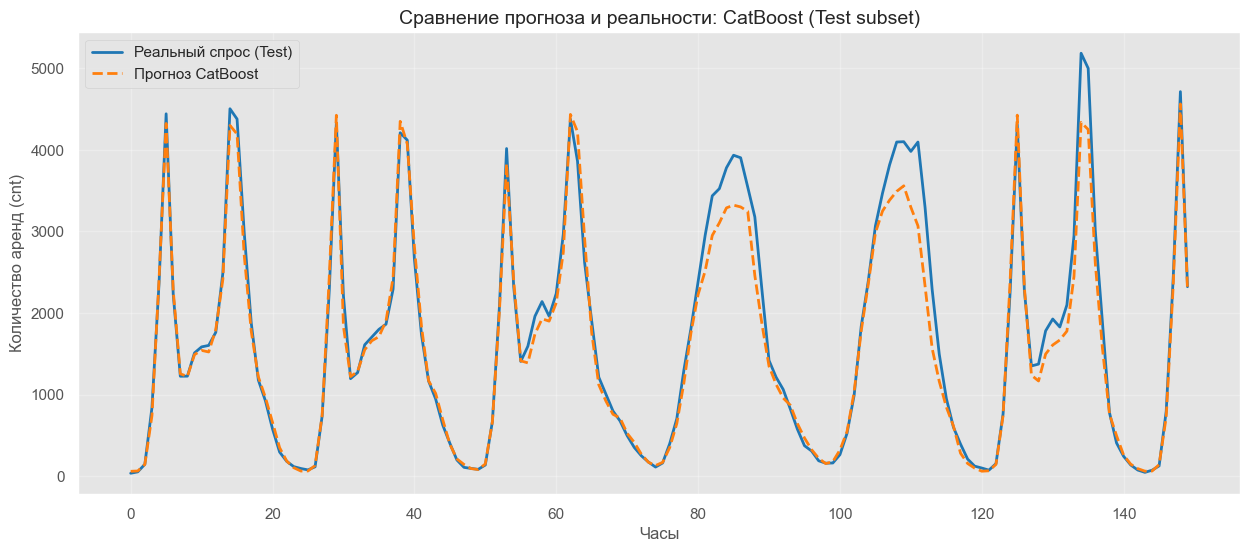

In [36]:
# Визуализируем первые 150 часов из тестовой выборки в исходном масштабе cnt
y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(15, 6))
plt.plot(
    y_test_real.values[:150],
    label="Реальный спрос (Test)",
    color="#1f77b4",
    linewidth=2,
)
plt.plot(
    y_test_pred_real[:150],
    label=f"Прогноз {best_model_name}",
    color="#ff7f0e",
    linestyle="--",
    linewidth=2,
)

plt.title(
    f"Сравнение прогноза и реальности: {best_model_name} (Test subset)", fontsize=14
)
plt.xlabel("Часы", fontsize=12)
plt.ylabel("Количество аренд (cnt)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Оценим интерпретируемость финальной модели `CatBoost` через важность признаков.

,feature,importance
16,hour_cos,45.116695
15,hour_sin,32.372082
17,day_of_week,6.143061
14,is_weekend_1.0,3.495361
13,is_weekend_0.0,3.078189
20,t2,2.043614
21,hum,1.686037
19,t1,1.308374
4,weather_code_7.0,1.303150
18,month,1.014698


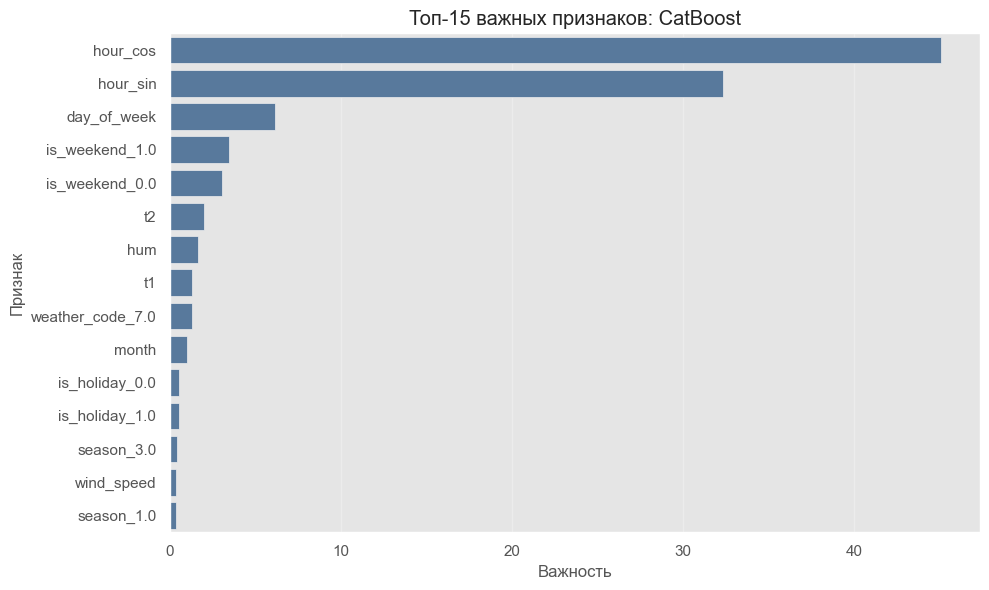

In [37]:
catboost_model = final_pipeline.named_steps["regressor"]
feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = catboost_model.feature_importances_

importance_df = pd.DataFrame(
    {"feature": feature_names, "importance": importances}
).sort_values("importance", ascending=False)

importance_df["feature"] = (
    importance_df["feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
)

top_features = importance_df.head(15)
display(top_features)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="importance", y="feature", color="#4c78a8")
plt.title("Топ-15 важных признаков: CatBoost")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()